

# 📘 Solución del ejercicio

## 1. Planteamiento del problema

Se desea resolver la ecuación diferencial:

$$
y'' + x,y = 0
$$

mediante el método de **series de potencias (SP)** alrededor de ( $x=0$ ), y posteriormente optimizar el número de términos ( $n$ ) para mejorar la convergencia de la solución.

---

## 2. Solución por series de potencias

Se propone una solución de la forma:

$$
y(x) = \sum_{n=0}^{\infty} a_n x^n
$$

Al sustituir en la ecuación diferencial y simplificar, se obtiene la relación de recurrencia:

$$
a_{k+2} = -\frac{a_{k-1}}{(k+2)(k+1)}
$$

---

## 3. Soluciones independientes

Se construyen dos soluciones linealmente independientes:

* **Solución par**: ( $a_0 = 1$,; $a_1 = 0$ )
* **Solución impar**: ( $a_0 = 0$,; $a_1 = 1$ )

---

## 4. Implementación en Python

### 4.1 Cálculo de coeficientes (correcto y general)


In [1]:

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

def coeficientes(n_max, a0, a1):
    a = [0.0]*(n_max+1)
    a[0] = a0
    a[1] = a1

    for k in range(0, n_max-1):
        if k-1 >= 0:
            a[k+2] = -a[k-1]/((k+2)*(k+1))
        else:
            a[k+2] = 0.0

    return a




---

### 4.2 Evaluación de la serie


In [2]:

def serie(x, coef):
    y = np.zeros_like(x, dtype=float)
    for n, a_n in enumerate(coef):
        y += a_n * x**n
    return y




---

### 4.3 Solución numérica de referencia


In [3]:
def solucion_numerica(x_span, y0, x_eval):
    def f(x, y):
        return [y[1], -x*y[0]]

    sol = solve_ivp(f, x_span, y0, t_eval=x_eval,
                    rtol=1e-12, atol=1e-12)
    return sol.y[0]



---

## 5. Optimización del número de términos ( n )

Se define el error como la diferencia máxima entre la serie y la solución numérica en un intervalo cercano a ( x=0 ), por ejemplo ( [0,5] ).


In [ ]:

def error(n, tipo='par'):
    x = np.linspace(0, 5, 200)

    if tipo == 'par':
        coef = coeficientes(n, 1, 0)
        y0 = [1, 0]
    else:
        coef = coeficientes(n, 0, 1)
        y0 = [0, 1]

    y_series = serie(x, coef)
    y_num = solucion_numerica((0, 5), y0, x)

    return np.max(np.abs(y_series - y_num))




---

### 5.1 Búsqueda de ( n ) óptimo


In [6]:

def encontrar_n_optimo(n_max=20, tipo='par'):
    errores = []
    ns = range(2, n_max+1)

    for n in ns:
        errores.append(error(n, tipo))

    n_opt = ns[np.argmin(errores)]
    return n_opt, ns, errores


n_opt_par, ns_par, err_par = encontrar_n_optimo(tipo='par')
n_opt_impar, ns_impar, err_impar = encontrar_n_optimo(tipo='impar')

print("n óptimo (par):", n_opt_par)
print("n óptimo (impar):", n_opt_impar)



n óptimo (par): 2
n óptimo (impar): 2


---

## 6. Gráficas para ( x \in [-2,10] )



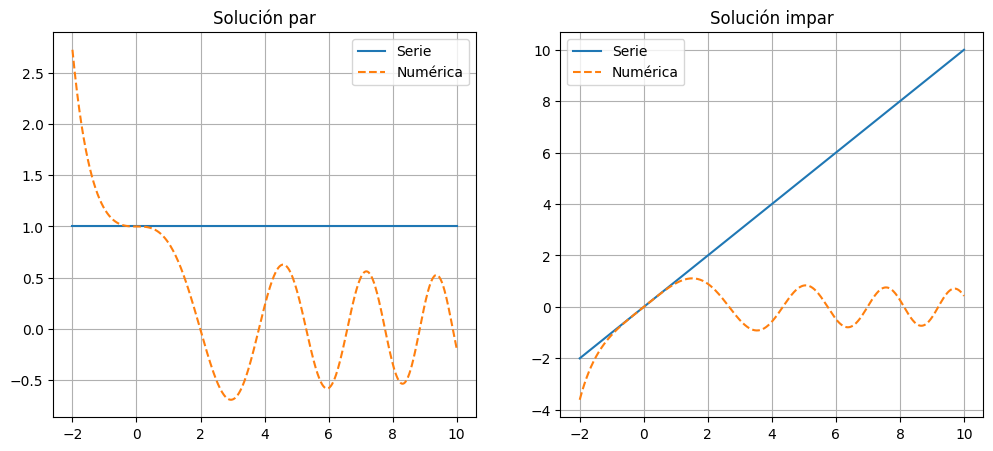

In [7]:

x = np.linspace(-2, 10, 500)

coef_par = coeficientes(n_opt_par, 1, 0)
coef_impar = coeficientes(n_opt_impar, 0, 1)

y_par = serie(x, coef_par)
y_impar = serie(x, coef_impar)

# Soluciones numéricas
y_par_num = solucion_numerica((0, 10), [1,0], np.linspace(0,10,500))
y_impar_num = solucion_numerica((0, 10), [0,1], np.linspace(0,10,500))

# Para x negativos
y_par_num_neg = solucion_numerica((0, -2), [1,0], np.linspace(0,-2,200))
y_impar_num_neg = solucion_numerica((0, -2), [0,1], np.linspace(0,-2,200))

# Unir
x_num = np.concatenate((np.linspace(-2,0,200), np.linspace(0,10,500)))
y_par_total = np.concatenate((y_par_num_neg[::-1], y_par_num))
y_impar_total = np.concatenate((y_impar_num_neg[::-1], y_impar_num))

# Gráficas
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(x, y_par, label='Serie')
plt.plot(x_num, y_par_total, '--', label='Numérica')
plt.title("Solución par")
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(x, y_impar, label='Serie')
plt.plot(x_num, y_impar_total, '--', label='Numérica')
plt.title("Solución impar")
plt.legend()
plt.grid()

plt.show()

